In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
from scipy.stats import spearmanr
from scipy.optimize import minimize_scalar
from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype':42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
import warnings
warnings.simplefilter("ignore")

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [3]:
expression_ann = sc.read_h5ad(input_file)

In [4]:
annotation_file = "full_annotation_df.csv"

In [5]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,Unnamed: 0,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993


In [6]:
target_gene_list = np.unique(annotation_df["closest_gene_target"])

In [7]:
target_region_dict = {}
target_gRNA_dict = {}

for gene in target_gene_list:
    target_list = np.unique(annotation_df[annotation_df["closest_gene_target"]== \
                                          gene]["gene_target"])
    target_region_dict[gene] = target_list

for gene in target_gene_list:
    target_list = np.unique(annotation_df[annotation_df["closest_gene_target"]== \
                                          gene]["protospacer_target"])
    target_gRNA_dict[gene] = target_list

In [8]:
gRNA_clear_list = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/20240903_CP2/Step1_sgRNA_outlier_pval_clear.csv",
                              index_col=0
                             )
gRNA_clear_list = gRNA_clear_list.index.tolist()

In [9]:
pval_sig_df = pd.read_csv("./Step2_pval_target_significant.csv",index_col=0)

In [10]:
sig_region_list = pval_sig_df["region_name"].values
sig_promoter_list = sig_region_list[[
    not (x.startswith("OR") or x.startswith("Element")) for x in sig_region_list]
]

In [11]:
sig_gene_name_tuple = []
for name in sig_promoter_list:
    annotation_sig_pro = annotation_df[annotation_df["gene_target"]==name]
    target_gene = annotation_sig_pro["closest_gene_target"].values[0]
    sig_gene_name_tuple += [(name,target_gene)]

In [12]:
gRNA_region_dict = {}

OR_gRNA_list = [i for i in gRNA_dict.keys() if i.startswith("OR")]
for gRNA_tmp in OR_gRNA_list:
    gene_name = gRNA_tmp.split("-")[0]
    if gRNA_tmp in gRNA_dict.keys():
        if gene_name in gRNA_region_dict.keys():
            gRNA_region_dict[gene_name] += [gRNA_tmp]
        else:
            gRNA_region_dict[gene_name] = [gRNA_tmp]

for index,row in annotation_df.iterrows():
    if row.protospacer_target in gRNA_dict.keys():
        if row.intended_target_region in gRNA_region_dict.keys():
            gRNA_region_dict[row.intended_target_region] += [row.protospacer_target]
        else:
            gRNA_region_dict[row.intended_target_region] = [row.protospacer_target]
for key in gRNA_region_dict.keys():
    gRNA_region_dict[key] = np.unique(gRNA_region_dict[key])

In [13]:
non_target_df = pd.read_csv("./Step2_non_targeting_gRNA_clean.csv")
gRNA_region_dict["non-targeting"] = non_target_df.values.reshape(-1).tolist()

In [14]:
def convert_name_region(target_name):
    return annotation_df[annotation_df["gene_target"]==target_name]["intended_target_region"].values[0]
def convert_region_name(target_region):
    return annotation_df[annotation_df["intended_target_region"]==target_region]["gene_target"].values[0]

<h4>Strategy</h4>
Focus on top 50 DEG.(25 upregulated/25 downregulated)<br>
make heatmap for each gRNA<br>

In [15]:
res_df = pd.read_csv("./gRNA_enhancer_edist.csv",index_col=0)

In [16]:
res_df

,gRNA_name,expression,edist,cell_num,target_gene,target_name,is_clear
0,chr1:236686500-236686518(-),0.242010,28.231201,82,ACTN2,ACTN2_P1P2,False
1,chr1:236686531-236686549(-),0.166434,15.448486,97,ACTN2,ACTN2_P1P2,True
2,chr1:236686545-236686563(-),0.186948,10.875977,226,ACTN2,ACTN2_P1P2,True
3,chr1:236686595-236686613(-),0.200017,4.378906,233,ACTN2,ACTN2_P1P2,True
4,chr1:236686598-236686616(-),0.151940,3.578613,268,ACTN2,ACTN2_P1P2,True
...,...,...,...,...,...,...,...
4106,chr19:58002768-58002787(+),0.110031,54.104370,93,ZNF814,Element768,False
4107,chr19:58002809-58002828(-),0.159527,17.276978,649,ZNF814,Element768,True
4108,chr19:58002864-58002883(+),0.183562,61.793701,144,ZNF814,Element768,False
4109,chr19:58002916-58002935(+),0.186861,10.624634,606,ZNF814,Element768,True


In [17]:
gRNA_region_name_dict = dict(res_df[["gRNA_name","target_name"]].values)

In [18]:
deg_df_file = "/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240919_WTC11_lenti_CMProduction2/pySpade/Manhattan_plots/filtered_df.csv"

In [19]:
deg_df = pd.read_csv(deg_df_file,index_col=0)

In [20]:
def error(a, x, y):
    return np.sum((y - (a * (x - 1) + 1))**2)

In [77]:
target_gene = "TBX20"
target_region_perturb = convert_name_region("TBX20_P1P2")

['SLC8A1' 'TNNI1' 'MYL7' 'AC009948.3' 'MYL4' 'TNNT2' 'TNNC1' 'MYH6' 'MYL3'
 'TPM1' 'CKM' 'CACNB2' 'TECRL' 'NEBL' 'TRH' 'HSPB7' 'CACNA1C' 'PLN'
 'SLC25A4' 'MDH1' 'TBX20']


100%|██████████| 105/105 [00:04<00:00, 23.50it/s]


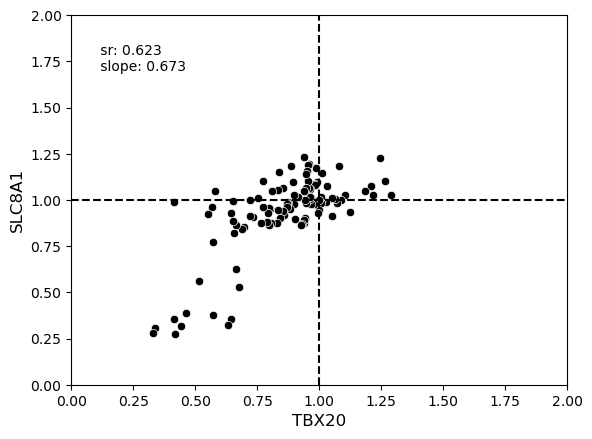

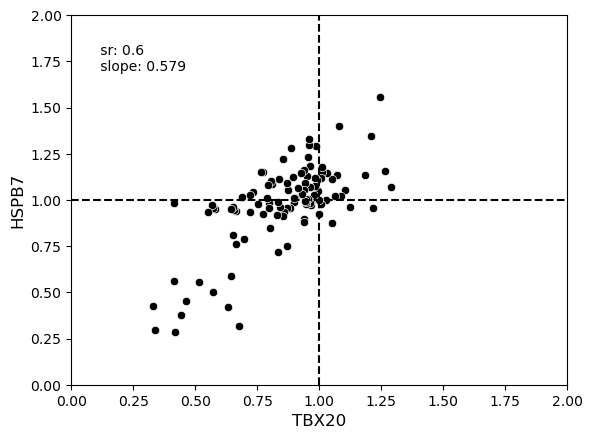

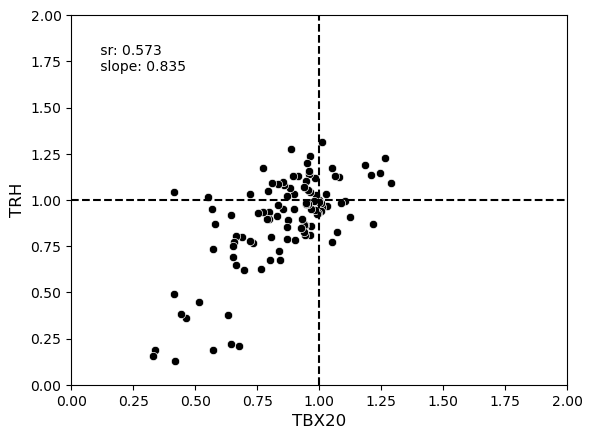

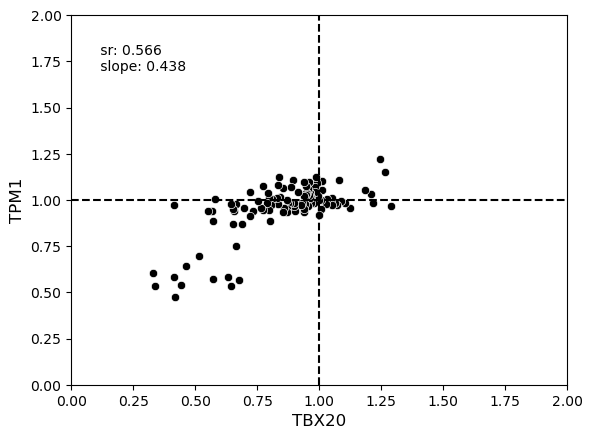

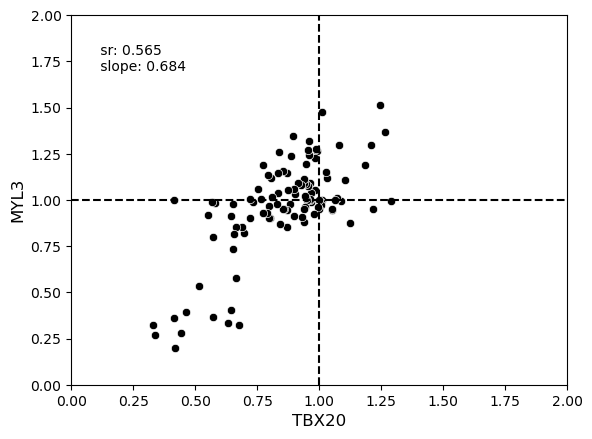

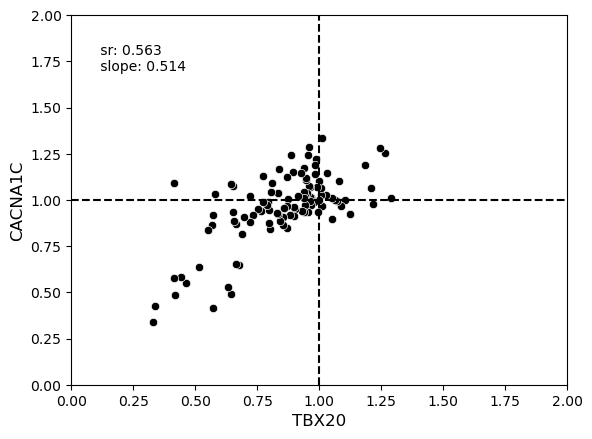

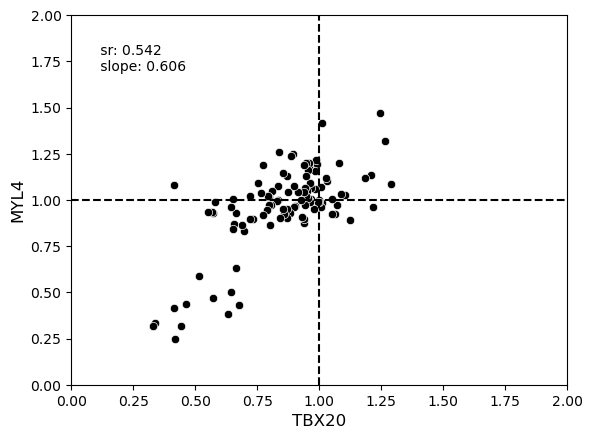

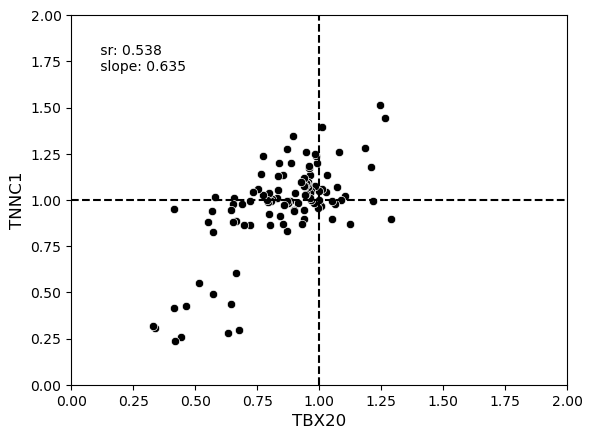

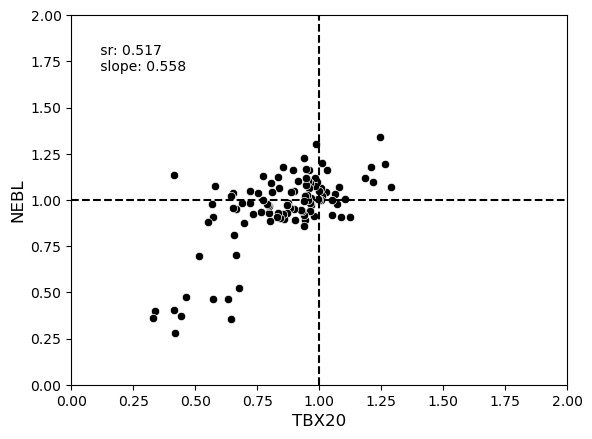

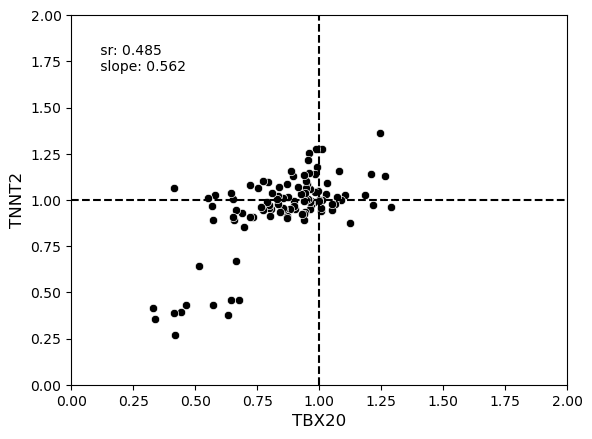

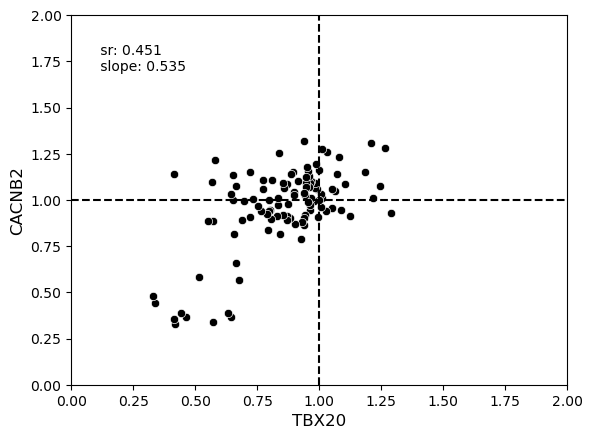

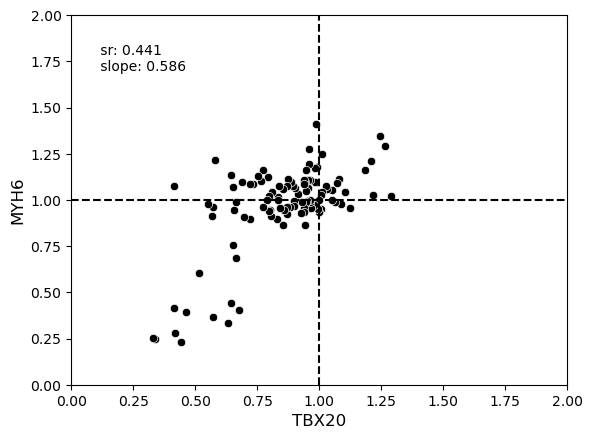

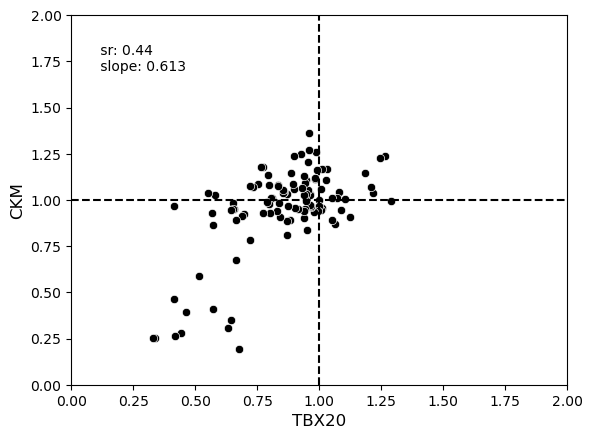

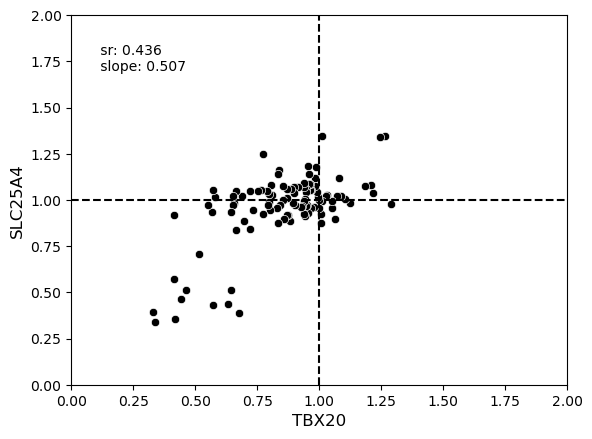

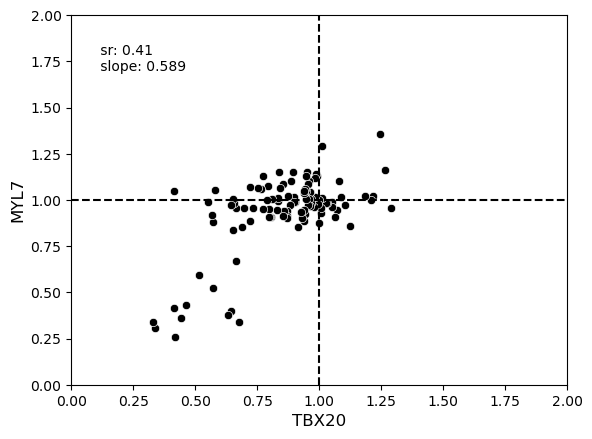

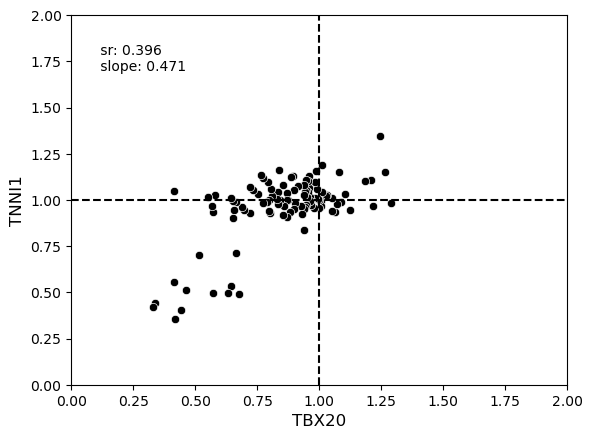

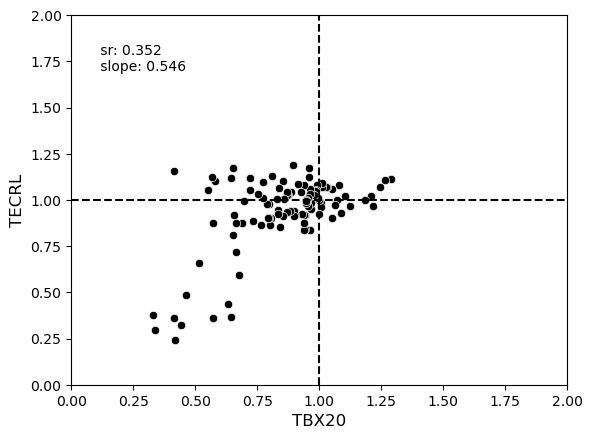

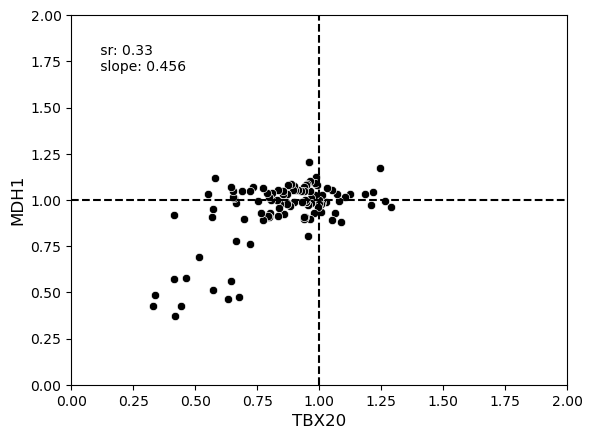

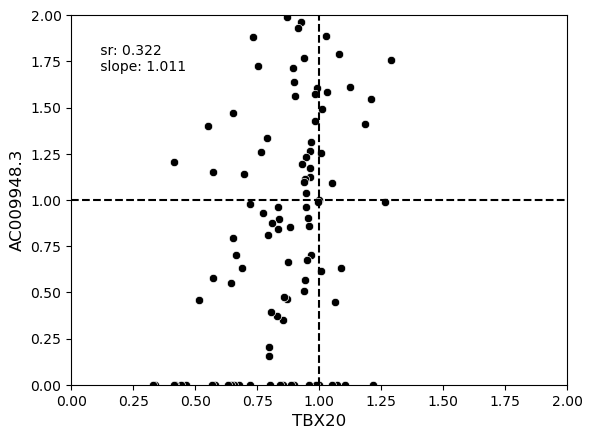

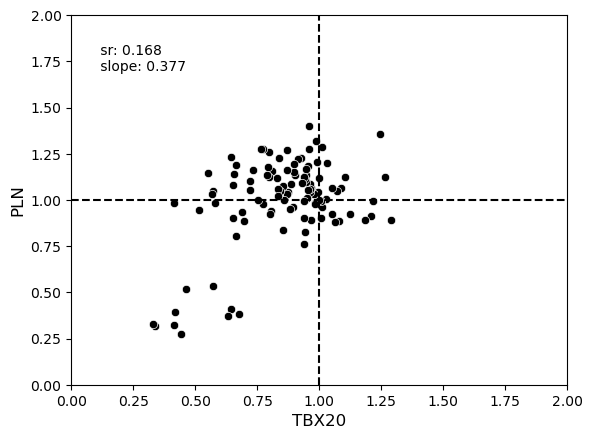

In [78]:
deg_df_region = deg_df[deg_df["region"]==target_region_perturb].sort_values("Significance_score")
top20_up_genes   = deg_df_region[deg_df_region["fc"]>1].iloc[:20]["gene_names"].values
top20_down_genes = deg_df_region[deg_df_region["fc"]<1].iloc[:20]["gene_names"].values

if not target_gene in top20_down_genes:
    top20_down_genes = np.concatenate([top20_down_genes,[target_gene]])
    
print(top20_down_genes)

top20_down_index = \
    [np.where(expression_ann.var.index==x)[0] for x in top20_down_genes]
top20_down_index = np.concatenate(top20_down_index)

top20_up_index = \
    [np.where(expression_ann.var.index==x)[0] for x in top20_up_genes]
top20_up_index = np.concatenate(top20_up_index)

non_targeting_cells_pick = np.concatenate([gRNA_dict[x] for x in gRNA_region_dict["non-targeting"]])
non_targeting_cells_pick = np.unique(non_targeting_cells_pick)
np.random.seed(1234)
non_targeting_cells_pick = np.random.choice(non_targeting_cells_pick,20000,replace=False)

non_target_cell_index = \
    np.where(expression_ann.obs.index.isin(non_targeting_cells_pick))[0]

exp_arr_down_nt = np.exp(expression_ann.raw.X[non_target_cell_index,:][:,top20_down_index].toarray())-1
exp_arr_up_nt = np.exp(expression_ann.raw.X[non_target_cell_index,:][:,top20_up_index].toarray())-1 

exp_arr_down_nt = np.mean(exp_arr_down_nt,axis=0)
exp_arr_up_nt = np.mean(exp_arr_up_nt,axis=0)

res_df_target = res_df[res_df["target_gene"] == target_gene]
gRNA_name_list_target = res_df_target["gRNA_name"].values[:-1]

gene_down_dict = {}
gene_up_dict = {}

for test_gRNA in tqdm(gRNA_name_list_target):
    test_cells = gRNA_dict[test_gRNA]
    test_cell_index = \
        np.where(expression_ann.obs.index.isin(test_cells))[0]
    
    exp_arr_down = np.exp(expression_ann.raw.X[test_cell_index,:][:,top20_down_index].toarray())-1
    exp_arr_up = np.exp(expression_ann.raw.X[test_cell_index,:][:,top20_up_index].toarray())-1 

    exp_arr_down = np.mean(exp_arr_down,axis=0)
    exp_arr_up = np.mean(exp_arr_up,axis=0)
    
    gene_down_dict[test_gRNA] = exp_arr_down
    gene_up_dict[test_gRNA] = exp_arr_up

gene_down_dict["non-targeting"] = exp_arr_down_nt
gene_up_dict["non-targeting"] = exp_arr_up_nt

gene_down_df = pd.DataFrame(gene_down_dict).T
gene_down_df.columns = top20_down_genes
gene_down_df = gene_down_df.sort_values(target_gene,ascending=False)

gene_down_df_norm = gene_down_df.div(gene_down_df.loc["non-targeting",:])
gene_down_df_norm["element_name"] = gene_down_df_norm.index.map(lambda x: gRNA_region_name_dict[x])

stat_arr = []
for test_gene in top20_down_genes:
    if test_gene != target_gene:
        spe_res = spearmanr(gene_down_df_norm[target_gene],gene_down_df_norm[test_gene])
        spe_res = spe_res.statistic
        
        x = gene_down_df_norm[target_gene].values
        y = gene_down_df_norm[test_gene].values
        result = minimize_scalar(error, args=(x, y))
        slope = result.x
        stat_arr += [[test_gene,spe_res,slope]]
stat_arr_df = pd.DataFrame(stat_arr,columns=["gene_name","spearmanr","slope"])
stat_arr_df = stat_arr_df.set_index("gene_name")
stat_arr_df = stat_arr_df.sort_values("spearmanr",ascending=False)

with PdfPages("./gRNA_level_fig/"+target_gene+"_down_deg.pdf") as pdf:
    for test_gene in stat_arr_df.index:
        spearman_test = round(stat_arr_df.at[test_gene,"spearmanr"],3)
        slope_test = round(stat_arr_df.loc[test_gene,"slope"],3)

        fig,ax = plt.subplots()
        sns.scatterplot(data=gene_down_df_norm,x=target_gene,y=test_gene,
                        ax=ax,c="black")
        ax.set_xlim(0,2)
        ax.set_ylim(0,2)
        #ax.plot((0,2),(val_0,val_2),c="black")
        ax.text(0.1,1.7," sr: "+str(spearman_test)+"\n slope: "+str(slope_test))
        ax.axvline(1.0,linestyle="--",c="black")
        ax.axhline(1.0,linestyle="--",c="black")
        
        pdf.savefig()
        plt.show()

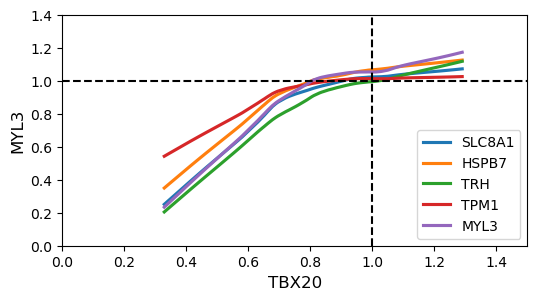

In [79]:
fig,ax = plt.subplots(figsize=(6,3))
for test_gene in stat_arr_df.index[:5]:
    sns.regplot(data=gene_down_df_norm,x=target_gene,y=test_gene,
                scatter=False, lowess=True,
                label=test_gene,ax=ax)

ax.legend()
ax.set_xlim(0,1.5)
ax.set_ylim(0,1.4)
ax.axvline(1.0,linestyle="--",c="black")
ax.axhline(1.0,linestyle="--",c="black")
plt.savefig("./gRNA_level_fig/"+target_gene+"_lowess.pdf")

In [23]:
stat_arr_df.index

Index(['SLC8A1', 'HSPB7', 'TRH', 'TPM1', 'MYL3', 'CACNA1C', 'MYL4', 'TNNC1',
       'NEBL', 'TNNT2', 'CACNB2', 'MYH6', 'CKM', 'SLC25A4', 'MYL7', 'TNNI1',
       'TECRL', 'MDH1', 'AC009948.3', 'PLN'],
      dtype='object', name='gene_name')

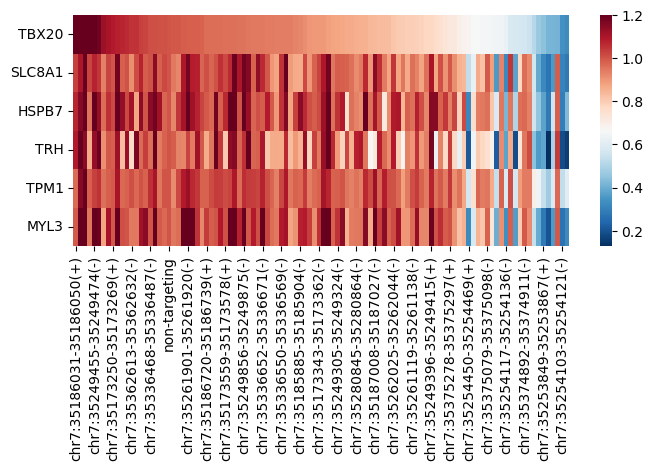

In [24]:
#heatmap_list = ['TBX5','TECRL', 'NPPA', 'TRH', 'CORIN', 'PLXNA4']
heatmap_list = ['TBX20','SLC8A1', 'HSPB7', 'TRH', 'TPM1', 'MYL3']
fig,ax = plt.subplots(figsize=(8,3))
sns.heatmap(gene_down_df_norm.loc[:,heatmap_list].T,vmax=1.2,cmap="RdBu_r")
plt.savefig("./gRNA_level_fig/"+target_gene+"_heatmap.pdf")